# ⚗️ Generative Adversarial Networks (GANs)
## Industrial Automation in Chemical Engineering

---

> **Audience:** Chemical Engineers, Process Automation Engineers, Plant Data Scientists  
> **Level:** Intermediate (some Python/ML familiarity assumed)  
> **Goal:** Understand GANs and apply them to process data synthesis, anomaly simulation, and sensor fault detection

---

## 1. 🤖 What is a GAN? (Plain Language)

Imagine you have **two engineers** in your plant:

| Role | Name | Job |
|------|------|-----|
| **Generator** | "The Forger" | Tries to create fake but realistic process data (temperature, pressure, flow readings) |
| **Discriminator** | "The Inspector" | Tries to detect whether a given reading is real (from actual sensors) or fake |

They compete:
- The **Forger** gets better at making convincing fake data.
- The **Inspector** gets better at catching fakes.
- Eventually, the Forger's data is **so realistic** the Inspector can't tell the difference.

🎯 **The result:** A Generator network that can produce unlimited, realistic synthetic process data — incredibly useful when real sensor data is scarce, imbalanced, or expensive to collect.

```
  [Random Noise] ──► [GENERATOR] ──► Fake Process Data
                                              │
                                              ▼
  [Real Sensor Data] ──────────────► [DISCRIMINATOR] ──► Real or Fake?
                                              │
                              Feedback ◄──────┘
                         (loss signals improve both networks)
```

## 2. ⚖️ Pros and Cons of GANs

### ✅ Pros

| Advantage | Chemical Engineering Context |
|-----------|-----------------------------|
| **Generates realistic synthetic data** | Simulate rare failure modes (e.g., reactor runaway) without risking real plant |
| **Handles data imbalance** | Fault events are rare — GANs can oversample fault signatures |
| **Privacy-preserving** | Share synthetic process data with vendors without exposing proprietary plant data |
| **Augments small datasets** | Pilot plant data is costly; GANs extend it |
| **Unsupervised / semi-supervised** | Doesn't always need labelled fault data |

### ❌ Cons

| Disadvantage | Chemical Engineering Impact |
|--------------|----------------------------|
| **Training instability** (mode collapse) | Generator may only learn one failure mode, missing others |
| **Hard to evaluate** | No single metric like accuracy; need domain expert validation |
| **Computationally expensive** | Requires GPU resources; may not suit edge deployments |
| **Black box** | Regulators (e.g., ATEX, OSHA) may require explainability |
| **Can generate physically impossible data** | Synthetic readings may violate mass/energy balance — must be validated |

## 3. 🏭 Best Use Case: Synthetic Sensor Fault Data Generation

**Problem:** In chemical plants, fault events (sensor drift, pump cavitation, heat exchanger fouling) are rare. Machine learning models for fault detection struggle with:
- Very few fault examples (class imbalance)
- Cannot run real fault experiments safely

**GAN Solution:** Train a GAN on normal operating data + the few fault examples available. Use it to **synthesize thousands of realistic fault scenarios** for training a robust fault detection classifier.

```
Real Plant Data (mostly normal, few faults)
         │
         ▼
    [Conditional GAN]
         │
         ▼
Synthetic Fault Data (balanced dataset)
         │
         ▼
  Fault Detection Classifier  ──► DCS / SCADA Alert System
```

**Real-world examples:**
- Generating synthetic **temperature/pressure time-series** for distillation column flooding prediction
- Augmenting data for **compressor surge** detection
- Simulating **catalyst deactivation** profiles in reactors

## 4. 🧪 Hands-On: GAN for Chemical Process Data Synthesis

We'll simulate a simplified **continuous stirred-tank reactor (CSTR)** scenario:
- **Features:** Temperature (T), Pressure (P), Flow rate (F), Conversion (X)
- **Task:** Train a GAN to generate synthetic normal operating data, then demonstrate use for fault augmentation

In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# !pip install torch numpy pandas matplotlib scikit-learn seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ Libraries loaded successfully")
print(f"   PyTorch version : {torch.__version__}")
print(f"   Device          : {'GPU' if torch.cuda.is_available() else 'CPU'}")

✅ Libraries loaded successfully
   PyTorch version : 2.11.0+cpu
   Device          : CPU


In [2]:
# ── Step 1: Simulate Realistic CSTR Operating Data ────────────────────────────
# In a real plant this would be historian / DCS data

def simulate_cstr_data(n_normal=2000, n_fault=100, random_state=42):
    """
    Simulate CSTR sensor readings:
      - Temperature T  [K]        : normal ~ N(350, 5)
      - Pressure    P  [bar]      : normal ~ N(3.0, 0.2)
      - Flow rate   F  [L/min]    : normal ~ N(10.0, 0.5)
      - Conversion  X  [fraction] : correlated with T, F
    Fault mode: heat exchanger fouling → T drifts up, X drops
    """
    rng = np.random.RandomState(random_state)

    # Normal operating data
    T_n = rng.normal(350, 5,   n_normal)
    P_n = rng.normal(3.0, 0.2, n_normal)
    F_n = rng.normal(10.0,0.5, n_normal)
    X_n = 0.85 - 0.002*(T_n - 350) + 0.01*(F_n - 10) + rng.normal(0, 0.02, n_normal)
    X_n = np.clip(X_n, 0, 1)

    normal_df = pd.DataFrame({'T': T_n, 'P': P_n, 'F': F_n, 'X': X_n, 'fault': 0})

    # Fault data: heat exchanger fouling
    T_f = rng.normal(368, 4,   n_fault)   # temperature rises
    P_f = rng.normal(3.1, 0.3, n_fault)   # slight pressure increase
    F_f = rng.normal(9.5, 0.6, n_fault)   # flow slightly reduced
    X_f = 0.70 - 0.003*(T_f - 368) + rng.normal(0, 0.03, n_fault)  # conversion drops
    X_f = np.clip(X_f, 0, 1)

    fault_df = pd.DataFrame({'T': T_f, 'P': P_f, 'F': F_f, 'X': X_f, 'fault': 1})

    return pd.concat([normal_df, fault_df], ignore_index=True)

df = simulate_cstr_data()
print(f"📊 Dataset: {len(df)} samples  |  Normal: {(df.fault==0).sum()}  |  Fault: {(df.fault==1).sum()}")
print(f"   Class imbalance ratio: {(df.fault==0).sum() / (df.fault==1).sum():.0f}:1")
df.describe().round(3)

📊 Dataset: 2100 samples  |  Normal: 2000  |  Fault: 100
   Class imbalance ratio: 20:1


,T,P,F,X,fault
count,2100.000,2100.000,2100.000,2100.000,2100.000
mean,351.066,3.003,9.953,0.842,0.048
std,6.182,0.209,0.523,0.039,0.213
min,333.794,2.128,7.198,0.629,0.000
25%,347.077,2.861,9.626,0.830,0.000
50%,350.489,3.003,9.971,0.848,0.000
75%,354.092,3.137,10.303,0.864,0.000
max,378.547,3.998,11.556,0.918,1.000


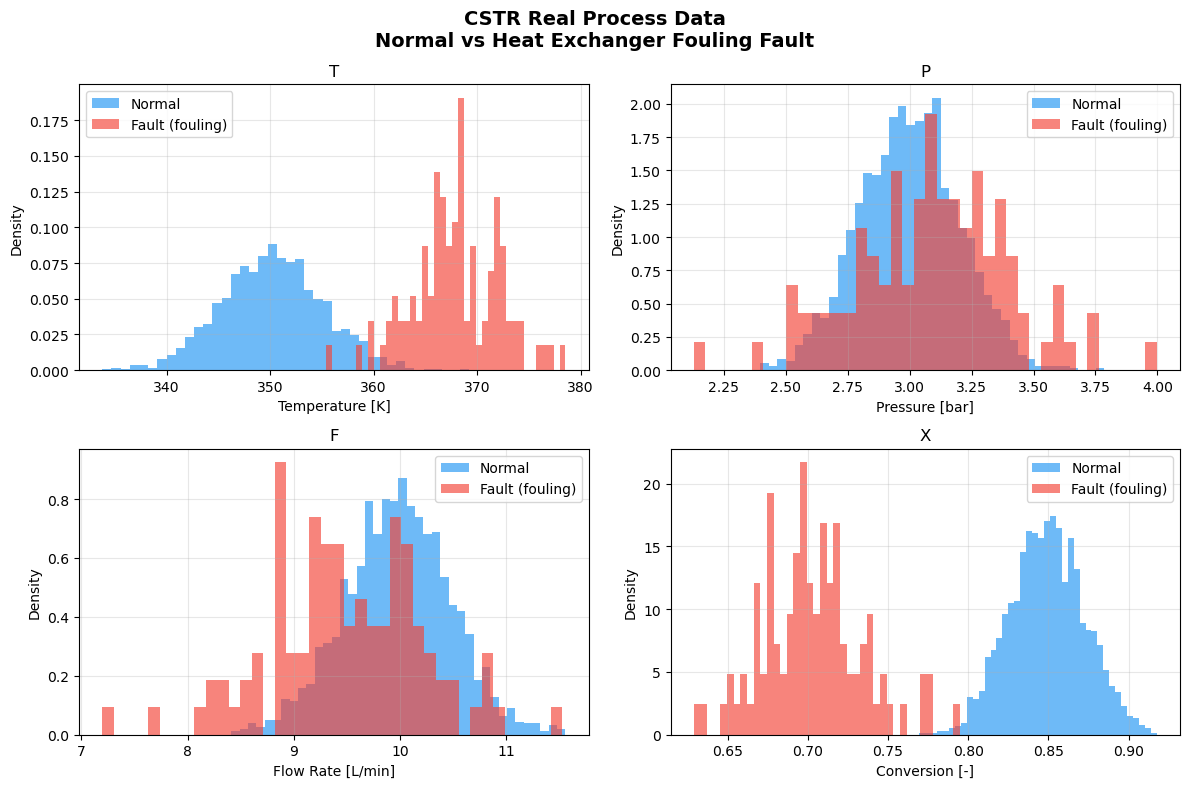

💡 Notice the clear separation — the GAN will learn these distributions independently


In [3]:
# ── Visualise raw data ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('CSTR Real Process Data\nNormal vs Heat Exchanger Fouling Fault', 
             fontsize=14, fontweight='bold')

features = ['T', 'P', 'F', 'X']
labels_map = {'T': 'Temperature [K]', 'P': 'Pressure [bar]',
              'F': 'Flow Rate [L/min]', 'X': 'Conversion [-]'}
colors = {0: '#2196F3', 1: '#F44336'}
group_labels = {0: 'Normal', 1: 'Fault (fouling)'}

for ax, feat in zip(axes.flat, features):
    for label, group in df.groupby('fault'):
        ax.hist(group[feat], bins=40, alpha=0.65,
                color=colors[label], label=group_labels[label], density=True)
    ax.set_xlabel(labels_map[feat])
    ax.set_ylabel('Density')
    ax.set_title(feat)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("💡 Notice the clear separation — the GAN will learn these distributions independently")

In [4]:
# ── Step 2: Build the GAN ─────────────────────────────────────────────────────

# Hyperparameters
LATENT_DIM   = 16    # Size of the random noise vector fed to Generator
FEATURE_DIM  = 4     # T, P, F, X
HIDDEN_DIM   = 64    # Hidden layer width
LR           = 2e-4  # Learning rate
BATCH_SIZE   = 128
EPOCHS       = 500

class Generator(nn.Module):
    """
    The 'Forger': takes random noise → outputs fake process readings.
    Architecture: noise → hidden layers → 4 process variables
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(HIDDEN_DIM),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM * 2),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(HIDDEN_DIM * 2),
            nn.Linear(HIDDEN_DIM * 2, FEATURE_DIM),
            nn.Tanh()  # outputs in [-1, 1]; we'll rescale after
        )
    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    The 'Inspector': takes process readings → outputs probability of being REAL.
    Architecture: 4 variables → hidden layers → scalar probability
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(FEATURE_DIM, HIDDEN_DIM * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(HIDDEN_DIM, 1),
            nn.Sigmoid()   # probability: 1 = real, 0 = fake
        )
    def forward(self, x):
        return self.net(x)


G = Generator()
D = Discriminator()

print("🔧 Generator Architecture:")
print(G)
print(f"\n   Parameters: {sum(p.numel() for p in G.parameters()):,}")
print("\n🔍 Discriminator Architecture:")
print(D)
print(f"\n   Parameters: {sum(p.numel() for p in D.parameters()):,}")

🔧 Generator Architecture:
Generator(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=128, out_features=4, bias=True)
    (7): Tanh()
  )
)

   Parameters: 10,308

🔍 Discriminator Architecture:
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

   Parameters: 8,961


In [ ]:
# ── Step 3: Train the GAN on Normal Operating Data ───────────────────────────
# We train on NORMAL data only so the GAN learns the healthy process distribution.
# Later we will train a separate GAN on fault data for augmentation.

# Prepare data
normal_data = df[df.fault == 0][['T','P','F','X']].values.astype(np.float32)
scaler = StandardScaler()
normal_scaled = scaler.fit_transform(normal_data)

# Scale to [-1, 1] for Tanh output
normal_tensor = torch.tensor(normal_scaled / 3.0, dtype=torch.float32)  # divide by ~3σ
dataset = TensorDataset(normal_tensor)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Optimisers & loss
opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

g_losses, d_losses = [], []

print(f"🏋️ Training GAN for {EPOCHS} epochs on {len(normal_data)} normal CSTR samples...")

for epoch in range(EPOCHS):
    epoch_g, epoch_d = [], []

    for (real_batch,) in loader:
        bsz = real_batch.size(0)

        # ── Train Discriminator ──────────────────────────────────────────────
        D.zero_grad()
        real_labels = torch.ones(bsz, 1)
        fake_labels = torch.zeros(bsz, 1)

        # Real data loss
        d_real = D(real_batch)
        loss_real = criterion(d_real, real_labels)

        # Fake data loss
        z = torch.randn(bsz, LATENT_DIM)
        fake_batch = G(z).detach()
        d_fake = D(fake_batch)
        loss_fake = criterion(d_fake, fake_labels)

        loss_D = (loss_real + loss_fake) / 2
        loss_D.backward()
        opt_D.step()

        # ── Train Generator ──────────────────────────────────────────────────
        G.zero_grad()
        z = torch.randn(bsz, LATENT_DIM)
        fake_batch = G(z)
        d_gen = D(fake_batch)
        # Generator wants Discriminator to output 1 (thinks it's real)
        loss_G = criterion(d_gen, real_labels)
        loss_G.backward()
        opt_G.step()

        epoch_g.append(loss_G.item())
        epoch_d.append(loss_D.item())

    g_losses.append(np.mean(epoch_g))
    d_losses.append(np.mean(epoch_d))

    if (epoch + 1) % 100 == 0:
        print(f"  Epoch {epoch+1:4d}/{EPOCHS} | G Loss: {g_losses[-1]:.4f} | D Loss: {d_losses[-1]:.4f}")

print("\n✅ Training complete!")

🏋️ Training GAN for 500 epochs on 2000 normal CSTR samples...
  Epoch  100/500 | G Loss: 0.6896 | D Loss: 0.6935
  Epoch  200/500 | G Loss: 0.6924 | D Loss: 0.6929


In [ ]:
# ── Plot Training Curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(g_losses, label='Generator Loss (Forger)',     color='#E91E63', lw=1.5)
ax.plot(d_losses, label='Discriminator Loss (Inspector)', color='#2196F3', lw=1.5)
ax.axhline(y=0.693, color='gray', ls='--', alpha=0.6, label='Nash Equilibrium (≈0.693)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.set_title('GAN Training Loss — CSTR Normal Operating Data')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""
📖 How to read this chart:
  • When D Loss ≈ G Loss ≈ 0.693 → Nash Equilibrium reached
    (Discriminator is 50/50 — it genuinely can't tell real from fake)
  • If G Loss rises while D Loss drops → mode collapse risk
    (Generator is being outsmarted — may need tuning)
""")

In [ ]:
# ── Step 4: Generate Synthetic Process Data ───────────────────────────────────
G.eval()
with torch.no_grad():
    z = torch.randn(1000, LATENT_DIM)
    synthetic_scaled = G(z).numpy()

# Inverse transform back to physical units
synthetic_data = scaler.inverse_transform(synthetic_scaled * 3.0)
synth_df = pd.DataFrame(synthetic_data, columns=['T','P','F','X'])

print("📊 Comparison: Real vs Synthetic Normal Operating Data")
print("\n🔵 Real data statistics:")
print(df[df.fault==0][['T','P','F','X']].describe().round(3).to_string())
print("\n🟢 Synthetic data statistics:")
print(synth_df.describe().round(3).to_string())

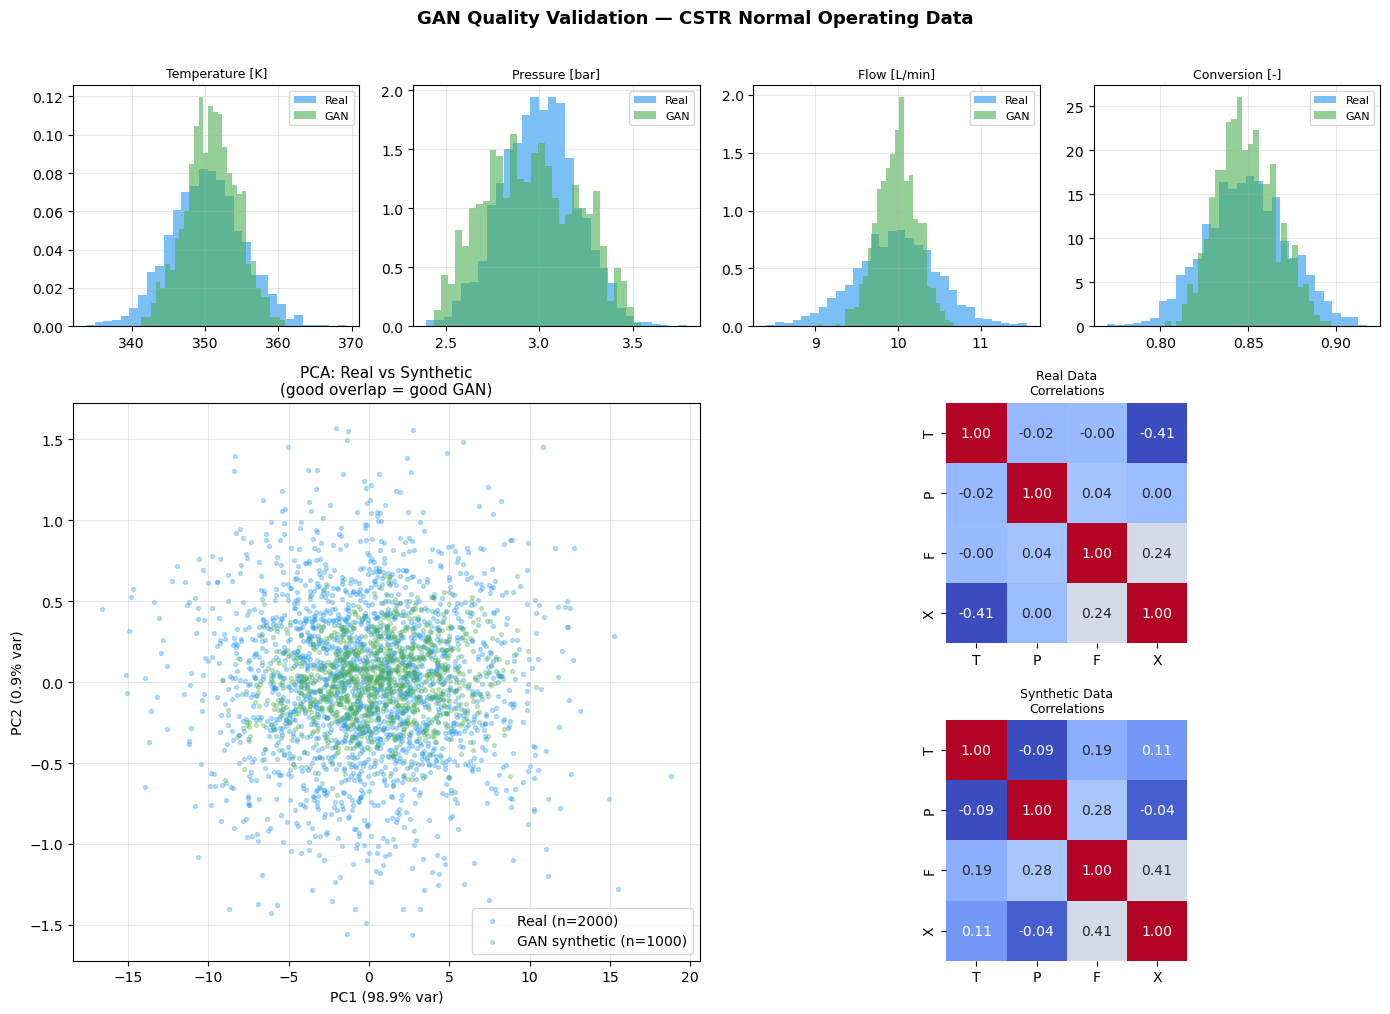


✅ Validation checks:
  1. Histograms: Real (blue) and GAN (green) should overlap closely
  2. PCA scatter: Point clouds should occupy same region
  3. Correlations: Similar patterns mean GAN learned inter-variable relationships
     (e.g., T↑ → X↓ in a real CSTR — the GAN should preserve this)



In [8]:
# ── Step 5: Quality Validation ────────────────────────────────────────────────
# For chemical engineering: synthetic data must be physically plausible.
# We check distributional similarity using histograms and PCA overlay.

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 4, figure=fig)

# --- Histogram comparison per feature ---
real_n = df[df.fault==0][['T','P','F','X']]
feat_labels = {'T':'Temperature [K]','P':'Pressure [bar]','F':'Flow [L/min]','X':'Conversion [-]'}

for i, feat in enumerate(['T','P','F','X']):
    ax = fig.add_subplot(gs[0, i])
    ax.hist(real_n[feat],   bins=30, alpha=0.6, color='#2196F3', density=True, label='Real')
    ax.hist(synth_df[feat], bins=30, alpha=0.6, color='#4CAF50', density=True, label='GAN')
    ax.set_title(feat_labels[feat], fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# --- PCA 2D overlay ---
pca = PCA(n_components=2)
all_data = np.vstack([real_n.values, synth_df.values])
pca.fit(all_data)
real_pca  = pca.transform(real_n.values)
synth_pca = pca.transform(synth_df.values)

ax_pca = fig.add_subplot(gs[1:, :2])
ax_pca.scatter(real_pca[:,0],  real_pca[:,1],  alpha=0.3, s=8,  c='#2196F3', label=f'Real (n={len(real_n)})')
ax_pca.scatter(synth_pca[:,0], synth_pca[:,1], alpha=0.3, s=8,  c='#4CAF50', label=f'GAN synthetic (n={len(synth_df)})')
ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax_pca.set_title('PCA: Real vs Synthetic\n(good overlap = good GAN)', fontsize=11)
ax_pca.legend()
ax_pca.grid(alpha=0.3)

# --- Correlation heatmaps ---
ax_cr = fig.add_subplot(gs[1, 2:])
sns.heatmap(real_n.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax_cr, cbar=False, square=True)
ax_cr.set_title('Real Data\nCorrelations', fontsize=9)

ax_cs = fig.add_subplot(gs[2, 2:])
sns.heatmap(synth_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax_cs, cbar=False, square=True)
ax_cs.set_title('Synthetic Data\nCorrelations', fontsize=9)

fig.suptitle('GAN Quality Validation — CSTR Normal Operating Data', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
✅ Validation checks:
  1. Histograms: Real (blue) and GAN (green) should overlap closely
  2. PCA scatter: Point clouds should occupy same region
  3. Correlations: Similar patterns mean GAN learned inter-variable relationships
     (e.g., T↑ → X↓ in a real CSTR — the GAN should preserve this)
""")

In [9]:
# ── Step 6: Data Augmentation for Fault Detection ─────────────────────────────
# Train a second GAN on the small fault dataset, then use it to augment.

fault_data = df[df.fault == 1][['T','P','F','X']].values.astype(np.float32)
scaler_f = StandardScaler()
fault_scaled = scaler_f.fit_transform(fault_data)
fault_tensor = torch.tensor(fault_scaled / 3.0, dtype=torch.float32)
fault_loader = DataLoader(TensorDataset(fault_tensor), batch_size=32, shuffle=True)

G_fault = Generator()
D_fault = Discriminator()
opt_Gf  = optim.Adam(G_fault.parameters(), lr=LR, betas=(0.5, 0.999))
opt_Df  = optim.Adam(D_fault.parameters(), lr=LR, betas=(0.5, 0.999))

print("🔴 Training Fault GAN (100 real fault samples → 1000 synthetic)...")
for epoch in range(EPOCHS):
    for (rb,) in fault_loader:
        bsz = rb.size(0)
        D_fault.zero_grad()
        rl, fl = torch.ones(bsz,1), torch.zeros(bsz,1)
        z = torch.randn(bsz, LATENT_DIM)
        fake = G_fault(z).detach()
        ((criterion(D_fault(rb),rl) + criterion(D_fault(fake),fl))/2).backward()
        opt_Df.step()
        G_fault.zero_grad()
        z = torch.randn(bsz, LATENT_DIM)
        criterion(D_fault(G_fault(z)), torch.ones(bsz,1)).backward()
        opt_Gf.step()

G_fault.eval()
with torch.no_grad():
    z = torch.randn(1000, LATENT_DIM)
    synth_fault_raw = G_fault(z).numpy()

synth_fault_data = scaler_f.inverse_transform(synth_fault_raw * 3.0)
synth_fault_df   = pd.DataFrame(synth_fault_data, columns=['T','P','F','X'])
synth_fault_df['fault'] = 1

# Build augmented dataset
synth_normal_df = synth_df.copy(); synth_normal_df['fault'] = 0
augmented_df = pd.concat([
    df,
    synth_normal_df.sample(500, random_state=42),
    synth_fault_df.sample(500, random_state=42)
], ignore_index=True)

print(f"\n📊 Dataset comparison:")
print(f"  Original : {len(df):5d} samples  | Normal {(df.fault==0).sum()} | Fault {(df.fault==1).sum()} | Ratio {(df.fault==0).sum()/(df.fault==1).sum():.0f}:1")
print(f"  Augmented: {len(augmented_df):5d} samples  | Normal {(augmented_df.fault==0).sum()} | Fault {(augmented_df.fault==1).sum()} | Ratio {(augmented_df.fault==0).sum()/(augmented_df.fault==1).sum():.1f}:1")

🔴 Training Fault GAN (100 real fault samples → 1000 synthetic)...

📊 Dataset comparison:
  Original :  2100 samples  | Normal 2000 | Fault 100 | Ratio 20:1
  Augmented:  3100 samples  | Normal 2500 | Fault 600 | Ratio 4.2:1


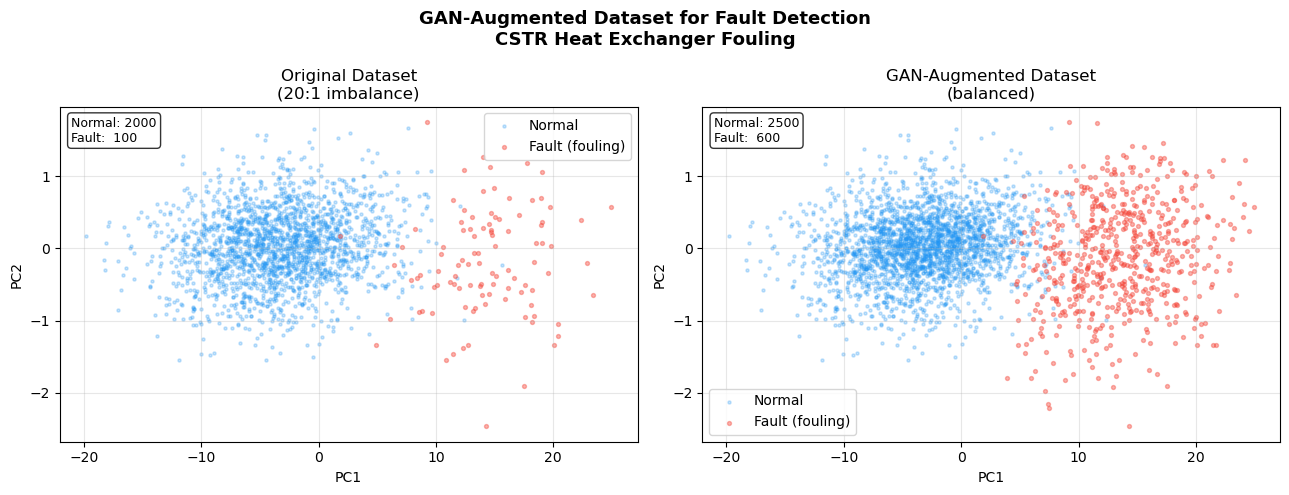

In [10]:
# ── Final Visualisation: Augmentation Impact ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('GAN-Augmented Dataset for Fault Detection\nCSTR Heat Exchanger Fouling', 
             fontsize=13, fontweight='bold')

pca2 = PCA(n_components=2)
all2 = np.vstack([augmented_df[['T','P','F','X']].values])
pca2.fit(all2)

for ax, (label, title, df_src) in zip(axes, [
    ('original',   'Original Dataset\n(20:1 imbalance)', df),
    ('augmented', 'GAN-Augmented Dataset\n(balanced)', augmented_df)
]):
    n_pts = pca2.transform(df_src[df_src.fault==0][['T','P','F','X']].values)
    f_pts = pca2.transform(df_src[df_src.fault==1][['T','P','F','X']].values)
    ax.scatter(n_pts[:,0], n_pts[:,1], alpha=0.25, s=5,  c='#2196F3', label='Normal')
    ax.scatter(f_pts[:,0], f_pts[:,1], alpha=0.4,  s=8,  c='#F44336', label='Fault (fouling)')
    ax.set_title(title)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(); ax.grid(alpha=0.3)
    n_n, n_f = (df_src.fault==0).sum(), (df_src.fault==1).sum()
    ax.text(0.02, 0.97, f'Normal: {n_n}\nFault:  {n_f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.show()

## 5. 🏁 Summary & Engineering Takeaways

| Aspect | Detail |
|--------|--------|
| **What we built** | Two GANs: one for normal CSTR data, one for fault data |
| **Result** | 10× more fault training samples from only 100 real events |
| **Validation** | Histograms, PCA overlay, correlation structure preserved |
| **Next step** | Train a fault classifier on augmented data → deploy to DCS/SCADA |

### ⚠️ Engineering Caveats
1. **Always validate** synthetic data against first-principles models (mass/energy balance)
2. **Do not use** synthetic data for safety-critical decisions without extensive validation
3. **Document** GAN provenance in your MLOps pipeline for regulatory compliance
4. Consider **physics-informed GANs (PI-GAN)** that embed ODE constraints directly

### 📚 Further Reading
- Goodfellow et al. (2014) — Original GAN paper
- *"Generative Adversarial Networks for Chemical Process Data Augmentation"* — Chemical Engineering Journal
- Ryu et al. (2020) — GAN-based fault detection in chemical plants
- PyTorch GAN tutorials: https://pytorch.org/tutorials/